# Question 5

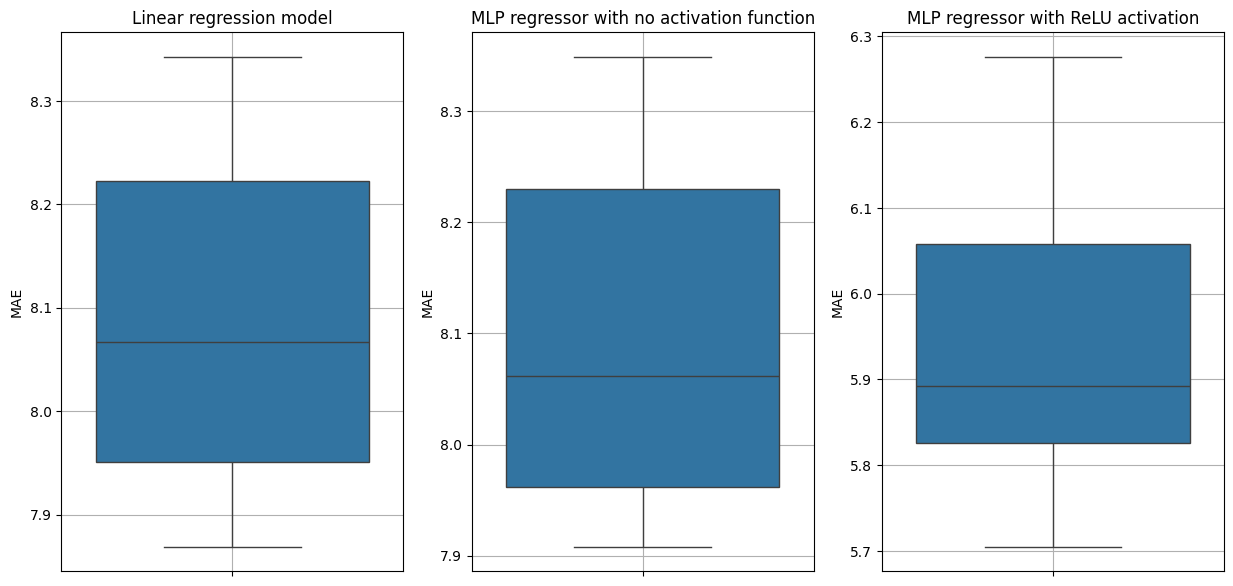

In [8]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_absolute_error
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from sklearn.exceptions import ConvergenceWarning

warnings.filterwarnings("ignore", category=ConvergenceWarning)

df = pd.read_csv("parkinsons.csv")
X = df.drop(columns=['target'])
y = df['target']

linear_MAE = []
mlp_no_activation_MAE = []
mlp_relu_MAE = []

for i in range(10):
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=i+1)
    lr = LinearRegression()
    lr.fit(X_train, y_train)
    pred_train_lr = lr.predict(X_test)
    linear_MAE.append(mean_absolute_error(y_test, pred_train_lr))

    mlp_no_activation = MLPRegressor(hidden_layer_sizes=(10, 10), activation='identity', random_state=0)
    mlp_no_activation.fit(X_train, y_train)
    pred_train_lr_mlp_no_activation = mlp_no_activation.predict(X_test)
    mlp_no_activation_MAE.append(mean_absolute_error(y_test, pred_train_lr_mlp_no_activation))

    mlp_relu = MLPRegressor(hidden_layer_sizes=(10, 10), activation='relu', random_state=0)
    mlp_relu.fit(X_train, y_train)
    pred_train_lr_mlp_relu = mlp_relu.predict(X_test)
    mlp_relu_MAE.append(mean_absolute_error(y_test, pred_train_lr_mlp_relu))

# Plotting
plt.figure(figsize=(15, 7))

plt.subplot(1, 3, 1)
sns.boxplot(data=linear_MAE)
plt.title('Linear regression model')
plt.ylabel('MAE')
plt.grid(True)

plt.subplot(1, 3, 2)
sns.boxplot(data=mlp_no_activation_MAE)
plt.title('MLP regressor with no activation function')
plt.ylabel('MAE')
plt.grid(True)

plt.subplot(1, 3, 3)
sns.boxplot(data=mlp_relu_MAE)
plt.title('MLP regressor with ReLU activation')
plt.ylabel('MAE')
plt.grid(True)

plt.show()

# Question 6

O modelo de regressão linear e o MLP sem funções de ativação apresentam desempenho semelhante, com valores de MAE bastante perto dos do outro. Isto deve-se ao facto de um MLP sem funções de ativação ser semelhante a um modelo de regressão linear, independentemente do número de camadas, pois o output das layers é essencialmente a soma linear dos inputs. Sem transformações não lineares, a rede não é capaz de modelar relações complexas nos dados, o que limita seu desempenho.
Por contraste, o MLP com ativação ReLU apresenta valores de MAE significativamente mais baixos. A função de ativação ReLU introduz a não linearidade no modelo, permitindo que o MLP aprenda padrões mais complexos nos dados que os modelos lineares não capazes de captar. Isso resulta em melhor desempenho, logo, menor MAE. Assim, é evidente a importância das funções de ativação nas redes neuronais.

# Question 7

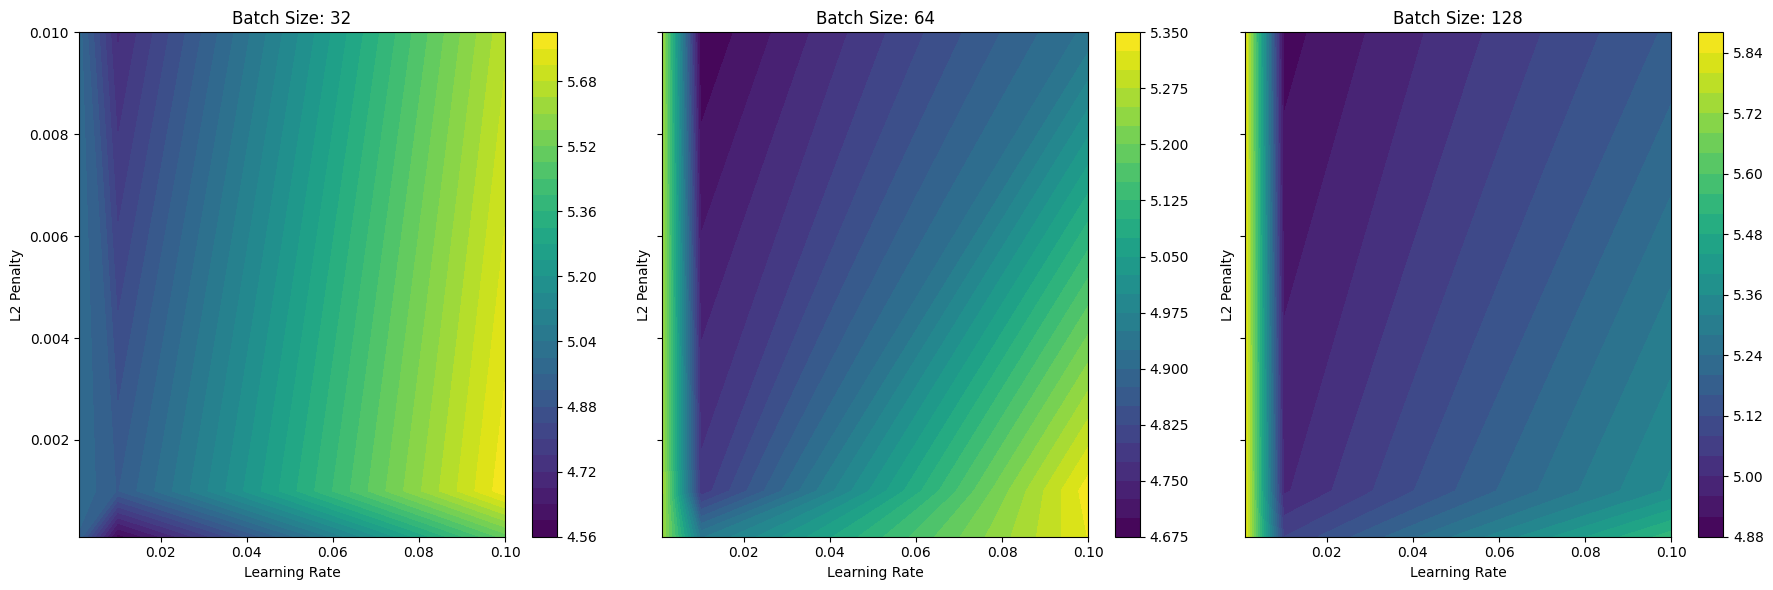

Best hyperparameters:
{'alpha': 0.0001, 'batch_size': 32, 'learning_rate_init': 0.01}
Best MAE: 4.5810


In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV, ShuffleSplit
from sklearn.neural_network import MLPRegressor
import warnings
from sklearn.exceptions import ConvergenceWarning

warnings.filterwarnings("ignore", category=ConvergenceWarning)

df = pd.read_csv("parkinsons.csv")
X = df.drop(columns=['target'])
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

param_grid = {
    'alpha': [0.0001, 0.001, 0.01],
    'learning_rate_init': [0.001, 0.01, 0.1],
    'batch_size': [32, 64, 128]
}

mlp = MLPRegressor(hidden_layer_sizes=(10, 10), random_state=0)

grid_search = GridSearchCV(mlp, param_grid, cv=5, scoring='neg_mean_absolute_error')
grid_search.fit(X_train, y_train)

results = grid_search.cv_results_
test_mae = -results['mean_test_score']
params = results['params']

alpha_values = [0.0001, 0.001, 0.01]
learning_rates = [0.001, 0.01, 0.1]
batch_sizes = [32, 64, 128]

MAE_matrix = np.zeros((len(alpha_values), len(learning_rates), len(batch_sizes)))
for index, param in enumerate(params):
    alpha_idx = alpha_values.index(param['alpha'])
    lr_idx = learning_rates.index(param['learning_rate_init'])
    batch_idx = batch_sizes.index(param['batch_size'])
    MAE_matrix[alpha_idx, lr_idx, batch_idx] = test_mae[index]

# Plotting
fig, ax = plt.subplots(1, len(batch_sizes), figsize=(18, 6), sharex=True, sharey=True)
for i, batch in enumerate(batch_sizes):
    c = ax[i].contourf(learning_rates, alpha_values, MAE_matrix[:, :, i], levels=30, cmap='viridis')
    ax[i].set_title(f'Batch Size: {batch}')
    ax[i].set_xlabel('Learning Rate')
    ax[i].set_ylabel('L2 Penalty')
    fig.colorbar(c, ax=ax[i])

plt.tight_layout()
plt.show()

best_params = grid_search.best_params_
best_mae = -grid_search.best_score_

print("Best hyperparameters:")
print(best_params)
print(f"Best MAE: {best_mae:.4f}")

Ao ajustar os hyperparameters para um MLPRegressor, os trade-offs envolvendo a regularização L2 (alfa), a taxa de aprendizagem (learning_rate_init) e o tamanho do batch são evidenciadas. Um alfa pequeno permite ao modelo capturar padrões complexos mas corre o risco de overfitting, enquanto um alfa grande reduz o overfitting à custa de um potencial underfitting. A taxa de aprendizagem afeta a rapidez com que o modelo actualiza os pesos, logo, uma taxa baixa assegura a estabilidade mas atrasa a convergência, enquanto uma taxa elevada acelera o treino mas pode perturbá-lo.
O tamanho do batch influencia a qualidade da atualização do gradiente, assim, tamanhos mais pequenos podem melhorar a generalização através de atualizações ruidosas mas podem tornar o treino mais lento, enquanto tamanhos maiores estabilizam as atualizações com o risco de redução da generalização.